# Local permittivity with subpixel averaging

This notebook demonstrates how to use local subpixel averaging in Tidy3D to obtain a more accurate permittivity profile, and more accurate results when running a [ModeSimulation](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.ModeSimulation.html) locally.

For more information about subpixel averaging, refer to [this lecture](https://www.flexcompute.com/fdtd101/Lecture-10-Introduction-to-subpixel-averaging/).

> The local subpixel averaging feature requires Tidy3D extras. You can install it with:
> ```
> pip install "tidy3d[extras]"
> ```

The notebook builds a three-layer dielectric stack and evaluates the local permittivity along a vertical line using [`Simulation.epsilon()`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.Simulation.html). The result is then compared against a full FDTD run using a [`PermittivityMonitor`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.PermittivityMonitor.html).

**Key concepts:**

- Without subpixel averaging, each interface is represented as a staircase on the Yee grid.
- With subpixel averaging, the local effective permittivity near a dielectric interface is smoothed to better represent the true filling fraction inside each cell.
- The largest difference between the two approaches appears near the waveguide boundaries; deep inside homogeneous regions both methods agree closely.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tidy3d as td
import tidy3d.web as web

td.config.logging_level = "ERROR"

## Geometry and Physical Parameters

A three-layer dielectric stack is embedded in a silica-like background ([`Medium`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.Medium.html) with n = 1.44). The stack is oriented along z with three 100 nm layers of increasing refractive index (n = 2, 3, 4). The line probe runs along z through the stack center and is used to query the local permittivity.

In [2]:
# Central wavelength and frequency used for all epsilon queries and monitors
wavelength = 1.55
freq0 = td.C_0 / wavelength

# Background medium
cladding_medium = td.Medium(permittivity=1.44**2)

# Layer media defined by refractive index
bottom_layer_medium = td.Medium(permittivity=2.0**2)
middle_layer_medium = td.Medium(permittivity=3.0**2)
top_layer_medium = td.Medium(permittivity=4.0**2)

# Lateral dimensions in micrometers
waveguide_width = 0.50
waveguide_length = 1e3

# Vertical stack definition in micrometers
layer_thickness = 0.10
stack_thickness = 3 * layer_thickness

# Simulation region dimensions in micrometers
sim_size_x = 4.0
sim_size_y = 2.0
sim_size_z = 4.0

# Mesh target
min_steps_per_wvl = 10

# Three stacked layers along z
bottom_layer_box = td.Box(
    center=(0.0, 0.0, -layer_thickness),
    size=(waveguide_length, waveguide_width, layer_thickness),
)

middle_layer_box = td.Box(
    center=(0.0, 0.0, 0.0),
    size=(waveguide_length, waveguide_width, layer_thickness),
)

top_layer_box = td.Box(
    center=(0.0, 0.0, layer_thickness),
    size=(waveguide_length, waveguide_width, layer_thickness),
)

bottom_layer = td.Structure(
    geometry=bottom_layer_box,
    medium=bottom_layer_medium,
    name="bottom_layer_n2",
)

middle_layer = td.Structure(
    geometry=middle_layer_box,
    medium=middle_layer_medium,
    name="middle_layer_n3",
)

top_layer = td.Structure(
    geometry=top_layer_box,
    medium=top_layer_medium,
    name="top_layer_n4",
)

stack_structures = [bottom_layer, middle_layer, top_layer]

# Box used for the local epsilon extraction.
# It is a line along z located at x=0 and y=0, crossing the stack vertically.
line_box = td.Box(
    center=(0.0, 0.0, 0.0),
    size=(0.0, 0.0, 1.0),
)

layer_boundaries = np.array(
    [
        -stack_thickness / 2,
        -stack_thickness / 2 + layer_thickness,
        -stack_thickness / 2 + 2 * layer_thickness,
        stack_thickness / 2,
    ]
)

## Helper to Build Simulations

The helper function keeps the geometry fixed and only toggles the `subpixel` flag and `td.config.simulation.use_local_subpixel`. When `include_source_and_monitor=True`, a dummy [`PlaneWave`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.PlaneWave.html) source and a [`PermittivityMonitor`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.PermittivityMonitor.html) are added to enable the FDTD run in Section 4.

In [3]:
def make_simulation(include_source_and_monitor=False):
    monitors = []
    sources = []

    if include_source_and_monitor:
        source_time = td.GaussianPulse(
            freq0=freq0,
            fwidth=0.2 * freq0,
        )

        plane_wave = td.PlaneWave(
            center=(0.0, 0.0, -0.6),
            size=(sim_size_x, sim_size_y, 0.0),
            source_time=source_time,
            direction="+",
        )

        permittivity_monitor = td.PermittivityMonitor(
            center=line_box.center,
            size=line_box.size,
            freqs=[freq0],
            name="eps_line_monitor",
        )

        sources = [plane_wave]
        monitors = [permittivity_monitor]

    sim = td.Simulation(
        size=(sim_size_x, sim_size_y, sim_size_z),
        center=(0.0, 0.0, 0.0),
        medium=cladding_medium,
        structures=stack_structures,
        sources=sources,
        monitors=monitors,
        grid_spec=td.GridSpec.auto(
            wavelength=wavelength,
            min_steps_per_wvl=min_steps_per_wvl,
        ),
        run_time=1e-14,
        boundary_spec=td.BoundarySpec.all_sides(td.PML()),
    )
    return sim

## Local Epsilon without and with Local Subpixel Averaging

Two [`Simulation`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.Simulation.html) objects are created, with and without local subpixel.

**`coord_key` options:**

- `"centers"` — samples at cell centers; returns the average of the diagonal permittivity components.
- `"Ex"`, `"Ey"`, `"Ez"` — samples at the corresponding Yee-grid field locations; returns `eps_xx`, `eps_yy`, `eps_zz`, respectively.

Here `coord_key="Ex"` is used so the local epsilon query is sampled at the same Yee-grid location as `PermittivityMonitor.eps_xx`, enabling a direct comparison in Section 4.

In [4]:
# Local epsilon without local subpixel averaging
td.config.simulation.use_local_subpixel = False
sim_no_subpixel = make_simulation(include_source_and_monitor=False)

eps_line_no_subpixel = sim_no_subpixel.epsilon(
    box=line_box,
    coord_key="Ex",
    freq=freq0,
)

# Local epsilon with local subpixel averaging
td.config.simulation.use_local_subpixel = True

sim_with_subpixel = make_simulation(include_source_and_monitor=False)

eps_line_with_subpixel = sim_with_subpixel.epsilon(
    box=line_box,
    coord_key="Ex",
    freq=freq0,
)

In [5]:
def extract_line_profile(eps_data):
    # For a line box, keep the non-singleton spatial axis.
    # The returned object can carry tensor components such as eps_xx, eps_yy, eps_zz.
    if hasattr(eps_data, "eps_xx"):
        data = eps_data.eps_xx
    else:
        data = eps_data

    squeezed = data.squeeze(drop=True)

    for axis_name in ("x", "y", "z"):
        if axis_name in squeezed.coords and squeezed.coords[axis_name].size > 1:
            coord = squeezed.coords[axis_name].values
            values = np.real(squeezed.values)
            return axis_name, coord, values

    raise RuntimeError("Could not identify the varying spatial coordinate in the epsilon data.")


axis_no_subpixel, coord_no_subpixel, values_no_subpixel = extract_line_profile(eps_line_no_subpixel)

axis_with_subpixel, coord_with_subpixel, values_with_subpixel = extract_line_profile(
    eps_line_with_subpixel
)

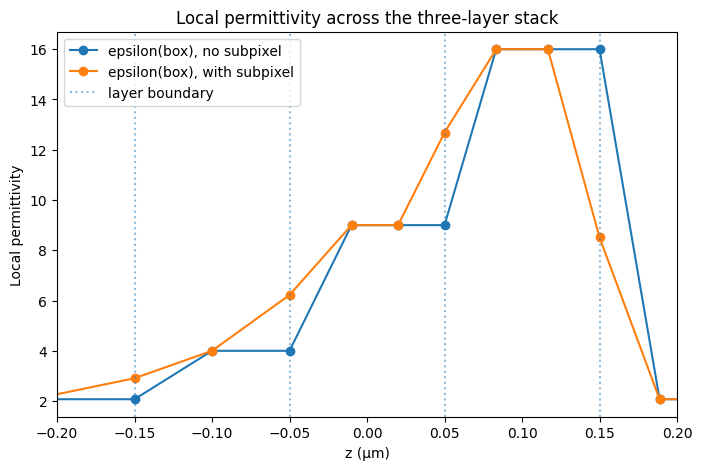

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(coord_no_subpixel, values_no_subpixel, "o-", label="epsilon(box), no subpixel")

ax.plot(
    coord_with_subpixel,
    values_with_subpixel,
    "o-",
    label="epsilon(box), with subpixel",
)

for boundary_index, boundary_position in enumerate(layer_boundaries):
    label = "layer boundary" if boundary_index == 0 else None
    ax.axvline(boundary_position, linestyle=":", alpha=0.5, label=label)

ax.set_xlabel(f"{axis_no_subpixel} (µm)")
ax.set_ylabel("Local permittivity")
ax.set_title("Local permittivity across the three-layer stack")
ax.legend()
ax.set_xlim(-0.2, 0.2)
plt.show()

The curves agree inside each homogeneous layer and differ mainly at the dielectric boundaries.

- The non-subpixel result transitions abruptly — each interface maps directly onto the nearest Yee cell edge.
- The subpixel result transitions smoothly — it approximates the effective filling fraction at each interface.
- The three 100 nm layers allow multiple interface transitions to be inspected in a single profile.


## FDTD Run with PermittivityMonitor

A minimal FDTD job (`run_time = 1e-14` s) is run to sample the permittivity via a [`PermittivityMonitor`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.PermittivityMonitor.html). The result is compared against the local epsilon computed in Section 3.

> The very short `run_time` is intentional — only the discretized permittivity is needed, not converged field data. A field-decay warning is expected.

In [7]:
sim_monitor = make_simulation(include_source_and_monitor=True)

sim_data = web.run(
    sim_monitor,
    task_name="subpixel_local_epsilon_dummy_monitor",
)

10:40:04 -03 Loading simulation from local cache. View cached task using web UI 
             at                                                                 
             ]8;id=391192;https://tidy3d.simulation.cloud/workbench?taskId=fdve-183ffa2a-eb1d-4ec0-a767-419517e0af7d\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=664462;https://tidy3d.simulation.cloud/workbench?taskId=fdve-183ffa2a-eb1d-4ec0-a767-419517e0af7d\taskId]8;;\]8;id=391192;https://tidy3d.simulation.cloud/workbench?taskId=fdve-183ffa2a-eb1d-4ec0-a767-419517e0af7d\=]8;;\]8;id=689641;https://tidy3d.simulation.cloud/workbench?taskId=fdve-183ffa2a-eb1d-4ec0-a767-419517e0af7d\fdve]8;;\]8;id=391192;https://tidy3d.simulation.cloud/workbench?taskId=fdve-183ffa2a-eb1d-4ec0-a767-419517e0af7d\-183ffa2a-eb1]8;;\
             ]8;id=391192;https://tidy3d.simulation.cloud/workbench?taskId=fdve-183ffa2a-eb1d-4ec0-a767-419517e0af7d\d-4ec0-a767-419517e0af7d']8;;\.

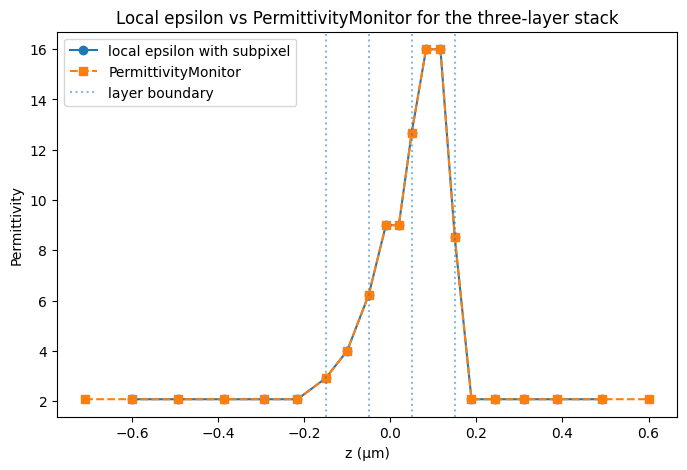

In [8]:
# Grab the monitored permittivity directly along the z line.
monitor_eps_xx = sim_data["eps_line_monitor"].eps_xx.squeeze(drop=True)
monitor_coord = monitor_eps_xx.coords["z"].values
monitor_values = np.real(monitor_eps_xx.values)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    coord_with_subpixel,
    values_with_subpixel,
    "o-",
    label="local epsilon with subpixel",
)
ax.plot(monitor_coord, monitor_values, "s--", label="PermittivityMonitor")

for boundary_index, boundary_position in enumerate(layer_boundaries):
    label = "layer boundary" if boundary_index == 0 else None
    ax.axvline(boundary_position, linestyle=":", alpha=0.5, label=label)

ax.set_xlabel("z (µm)")
ax.set_ylabel("Permittivity")
ax.set_title("Local epsilon vs PermittivityMonitor for the three-layer stack")
ax.legend()
plt.show()

As we can see, the local subpixel matches exactly the grid used in cloud computation.
